In [1]:
import os
import pandas as pd
import numpy as nm
import matplotlib.pyplot as plt
from datetime import date
from datetime import timedelta

In [2]:
df_orders = pd.read_csv(r'/Users/mohil/Desktop/DataSets/Olist_Brazil/olist_orders_dataset.csv')

In [2]:
df_orders = pd.read_csv(r'/Users/mohil/Desktop/DataSets/Olist_Brazil/olist_orders_dataset.csv')

In [3]:
df_items = pd.read_csv(r'/Users/mohil/Desktop/DataSets/Olist_Brazil/olist_order_items_dataset.csv')

In [4]:
df_customers = pd.read_csv(r'/Users/mohil/Desktop/DataSets/Olist_Brazil/olist_customers_dataset.csv')

In [5]:
df_geo = pd.read_csv(r'/Users/mohil/Desktop/DataSets/olist_geolocation_clean_BI - olist_geolocation_clean_BI.csv.csv')

In [6]:
df_payments = pd.read_csv(r'/Users/mohil/Desktop/DataSets/Olist_Brazil/olist_order_payments_dataset.csv')

In [7]:
df_review = pd.read_csv(r'/Users/mohil/Desktop/DataSets/Olist_Brazil/olist_order_reviews_cleaned.csv')

In [8]:
df_product = pd.read_csv(r'/Users/mohil/Desktop/DataSets/Olist_Brazil/olist_products_dataset.csv')

In [9]:
df_seller = pd.read_csv(r'/Users/mohil/Desktop/DataSets/Olist_Brazil/olist_sellers_dataset.csv')

In [10]:
df_pro_category = pd.read_csv(r'/Users/mohil/Desktop/DataSets/Olist_Brazil/product_category_name_translation.csv')

In [16]:
dates = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

In [19]:
for x in dates:
    df_orders[x] = pd.to_datetime(df_orders[x])

Skewness: 9.25 | Heavily Rightly Skewed
Mean: R$154.1 | Median: R$100.0
95th percentile: R$438.0 | Max: R$13664.08


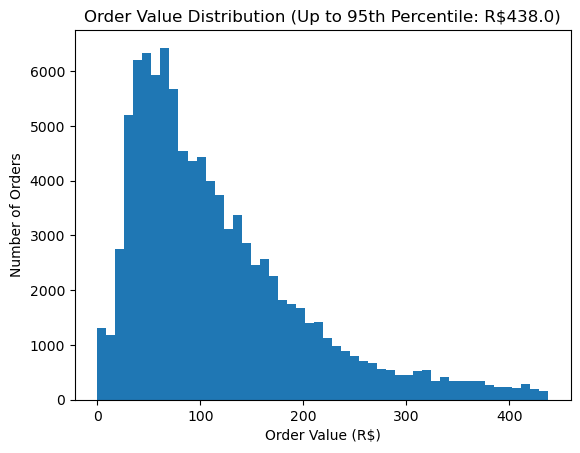

In [51]:
pcntl = df_payments['payment_value'].quantile(0.95)
plt.hist(df_payments[df_payments['payment_value'] <= pcntl]['payment_value'], 
             bins=50)
plt.title(f'Order Value Distribution (Up to 95th Percentile: R${pcntl.round():})')
plt.xlabel('Order Value (R$)')
plt.ylabel('Number of Orders')
plt.savefig('order_value_distribution.png', dpi=150, bbox_inches='tight')

print(f"Skewness: {df_payments['payment_value'].skew().round(2):} | Heavily Rightly Skewed")
print(f"Mean: R${df_payments['payment_value'].mean().round(2):} | Median: R${df_payments['payment_value'].median():}")
print(f"95th percentile: R${pcntl.round():} | Max: R${df_payments['payment_value'].max():}")

In [53]:
delay = df_orders['order_delivered_customer_date']-df_orders['order_estimated_delivery_date']

In [58]:
delay = delay[delay > pd.Timedelta(0)]

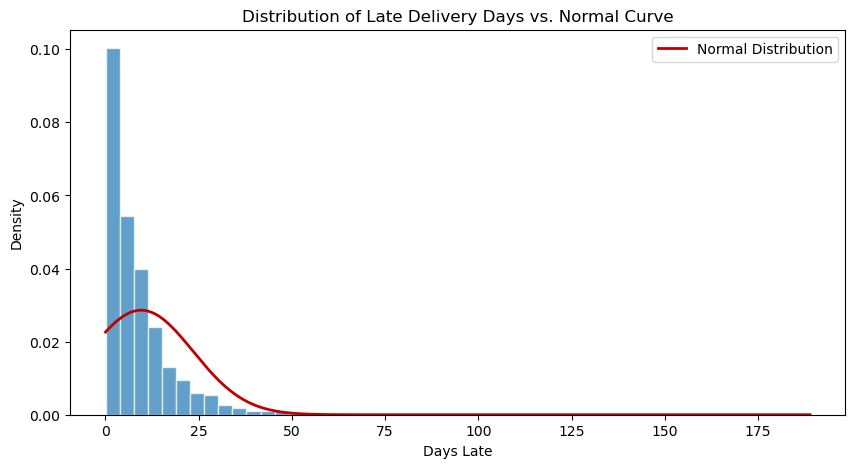

Mean delay: 9.55 days | Std Dev: 13.95 days
Skewness: 5.42


In [105]:
delay_days = delay.dt.total_seconds()/86400
mu, sigma = delay_days.mean(), delay_days.std()
x = np.linspace(delay_days.min(), delay_days.max(), 1000)
normal_curve = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(x-mu)**2/(2*sigma**2))
plt.figure(figsize=(10,5))
plt.hist(delay_days, bins=50, density=True, edgecolor='white', alpha=0.7)
plt.plot(x, normal_curve, color='#C00000', linewidth=2, label='Normal Distribution')
plt.title('Distribution of Late Delivery Days vs. Normal Curve')
plt.xlabel('Days Late')
plt.ylabel('Density')
plt.legend()
plt.savefig('delay_distribution_normal.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mean delay: {mu:.2f} days | Std Dev: {sigma:.2f} days")
print(f"Skewness: {delay_days.skew():.2f}")

In [85]:
df_orders['delays'] = delay

In [93]:
pd.set_option('display.max.rows', 10000)

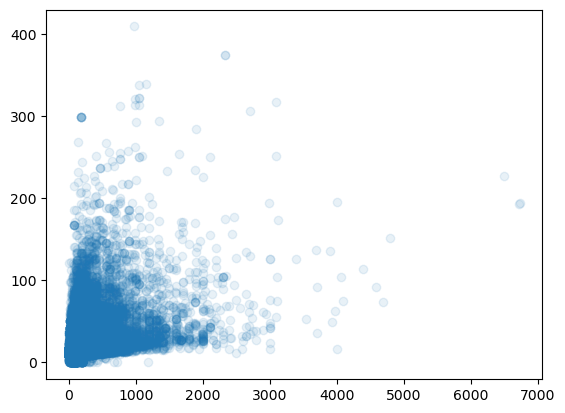

In [103]:
plt.scatter(df_items['price'], df_items['freight_value'], alpha=0.1)
plt.savefig('Freight Value vs Distance Proxy.png', dpi=150, bbox_inches='tight') 

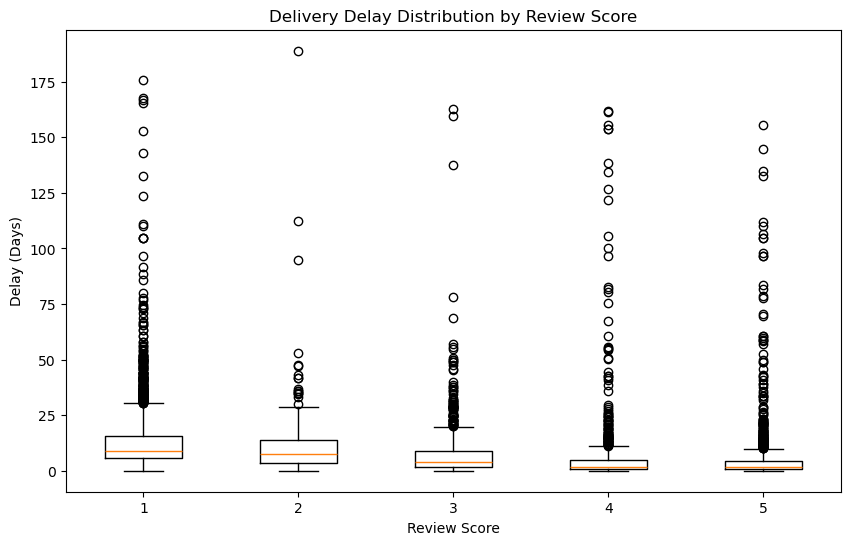

In [131]:
df = df_orders[['order_id', 'delays']].merge(df_review[['order_id', 'review_score']], on='order_id')
df = df.dropna(subset=['delays', 'review_score'])
x = [df_combined[df_combined['review_score'] == score]['delays'].dt.total_seconds()/86400 
                 for score in sorted(df_combined['review_score'].unique())]

plt.figure(figsize=(10,6))
plt.boxplot(x, tick_labels=sorted(df_combined['review_score'].unique()))
plt.title('Delivery Delay Distribution by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Delay (Days)')
plt.savefig('delay_by_review_boxplot.png', dpi=150, bbox_inches='tight')

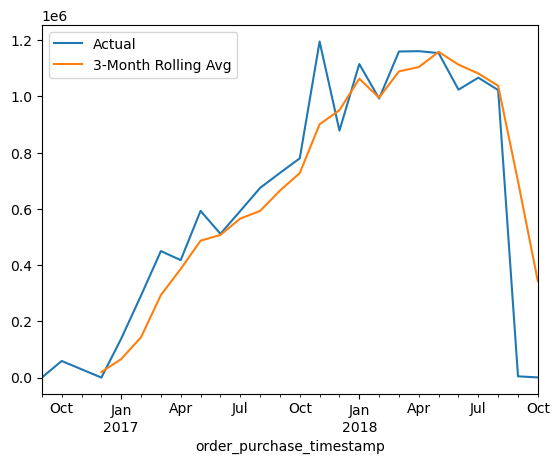

<Figure size 1000x500 with 0 Axes>

In [117]:
df = df_orders.merge(df_payments, how='inner', on='order_id')
monthly = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['payment_value'].sum()
monthly_rolling = monthly.rolling(window=3).mean()
monthly.plot(label='Actual')
monthly_rolling.plot(label='3-Month Rolling Avg')
plt.legend()
plt.figure(figsize=(10,5)) 
plt.savefig('Rolling 3-month average GMV.png', dpi=150, bbox_inches='tight')

<Axes: xlabel='order_purchase_timestamp'>

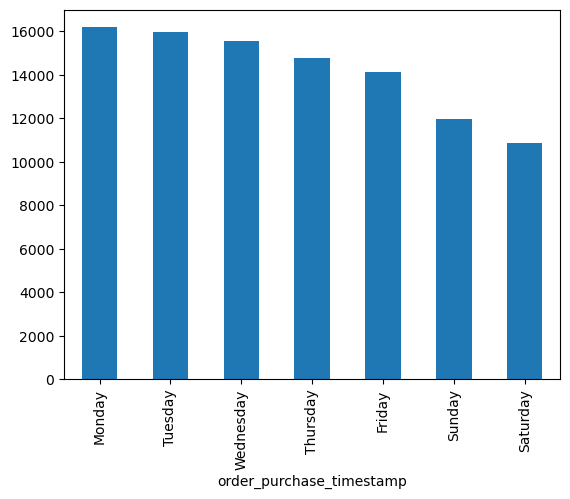

In [118]:
df_orders['order_purchase_timestamp'].dt.day_name().value_counts().plot(kind='bar')

<Axes: xlabel='order_purchase_timestamp'>

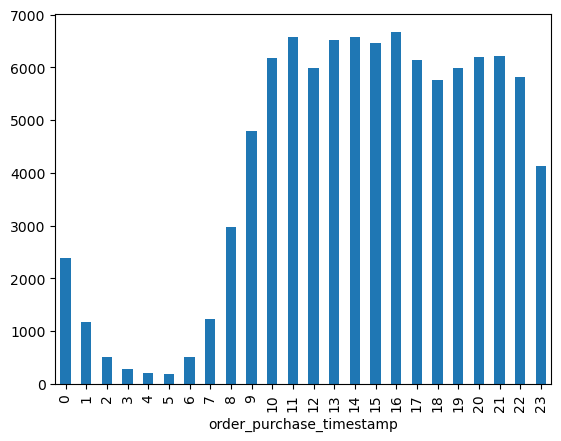

In [121]:
df_orders['order_purchase_timestamp'].dt.hour.value_counts().sort_index().plot(kind='bar')


In [126]:
df = df_orders.merge(df_customers, how='inner', on='customer_id').merge(df_payments, how='inner', on='order_id')
snapshot_date = df['order_purchase_timestamp'].max()
rfm = df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
)
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [127]:
rfm

,recency,frequency,monetary,R_score,F_score,M_score,RFM_Score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,1,4,414
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1,411
0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,4,214
...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,495,1,2067.42,1,5,5,155
fffea47cd6d3cc0a88bd621562a9d061,310,1,84.58,3,5,2,352
ffff371b4d645b6ecea244b27531430a,617,1,112.46,1,5,3,153


In [ ]:
from scipy import stats
df= df_orders.merge(df_items, how='inner', on='order_id').merge(df_seller, how='inner', on='seller_id')
go_delay = df[df['seller_state']=='GO']['delay'].dropna()
sp_delay = df[df['seller_state']=='SP']['delay'].dropna()
t_stat, p_value = stats.ttest_ind(go_delay, sp_delay)
print(f"p-value: {p_value}")  